<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [155]:
#Importation de la librairie Pandas
import pandas as pd
#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

In [156]:
#Importation de la librairie plotly express
import plotly.express as px

In [157]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

# https://stackoverflow.com/questions/49188960/how-to-show-all-columns-names-on-a-large-pandas-dataframe
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [158]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

c:\Users\MonCompte\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed

c:\Users\MonCompte\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed

c:\Users\MonCompte\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [159]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [160]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

Le tableau comporte 6 colonne(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [161]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [162]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
duplicates = df_erp[df_erp.duplicated(subset='product_id')]
duplicates

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [163]:
# pas de doublons
# #on peut vérifier si on a bien 825 valeurs uniques
nb_id = df_erp['product_id'].unique()
len(nb_id)

825

In [164]:
#Afficher les valeurs distinctes de la colonne stock_status
val_stock_status = df_erp['stock_status'].unique()
print(val_stock_status)

['instock' 'outofstock']


In [165]:
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_out_of_stock = df_erp.loc[df_erp['stock_status'] == 'outofstock']
df_out_of_stock

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
2,3850,1,20.8,0,outofstock,10.64
4,4039,1,46.0,3,outofstock,23.77
8,4043,1,60.0,0,outofstock,29.45
11,4047,1,18.3,0,outofstock,9.93
15,4051,1,7.7,0,outofstock,4.14
...,...,...,...,...,...,...
723,6301,1,40.5,0,outofstock,20.51
726,6327,0,28.5,0,outofstock,14.43
752,6632,1,52.7,0,outofstock,26.41
774,6900,0,30.0,0,outofstock,16.28


In [166]:
# Je suppose product_id et stock_quantity

In [167]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"

df_erp['stock_status_2'] = 'instock' #On crée la colonne en mettant "instock" partout.
df_erp.loc[df_erp['stock_quantity'] <= 0, "stock_status_2"] = "outofstock" # On modifie les lignes ou le stock est inférieur ou égal à 0 pour y mettre "outofstock"
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [168]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]
#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [169]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset
sum(df_erp["stock_status"] == df_erp["stock_status_2"])


823

In [170]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
# https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [171]:
#Corriger la ou les données incohérentes

# On remet le bon label comme fait sur stock_status_2
df_erp.loc[df_erp['stock_quantity'] < 1, 'stock_status'] = 'outofstock'
df_erp.loc[df_erp['stock_quantity'] >= 1, 'stock_status'] = 'instock'

In [172]:
# On vérifie avec une condition
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


In [173]:
#Vérification en utilisant le même code que plus haut pour afficher les problèmes

# Ou en vérifiant que la somme des 'True' = 825
sum(df_erp["stock_status"] == df_erp["stock_status_2"])

825

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [174]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isnull().sum())) #Saisir l'instruction manquante dans la fonction format

Nombres d'articles avec un prix non renseigné: 0


In [175]:
#Afficher le prix minimum de la colonne "price"
print("Prix minimum sur un article: {} €".format(df_erp['price'].min()))

Prix minimum sur un article: -20.0 €


In [176]:
#Afficher le prix maximum de la colonne "price"
print("Prix maximum sur un article: {} €".format(df_erp['price'].max()))

Prix maximum sur un article: 225.0 €


In [177]:
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("liste des prix inférieurs à 0 :  {}".format(df_erp.loc[df_erp['price'] < 0, 'price'].unique()))

liste des prix inférieurs à 0 :  [-20.   -8.   -9.1]


In [178]:
#Je pense que le mieux est de les supprimer
df_erp = df_erp[~(df_erp['price'] < 0)]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [179]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
print("Nombres d'articles avec un stock non renseigné: {}".format(df_erp['stock_quantity'].isnull().sum()))

Nombres d'articles avec un stock non renseigné: 0


In [180]:
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum sur un article: {}.".format(df_erp['stock_quantity'].min()))

Quantité minimum sur un article: -10.


In [181]:
#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum sur un article: {}.".format(df_erp['stock_quantity'].max()))

Quantité maximum sur un article: 145.


In [182]:
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("liste des stocks inférieurs à 0 :  {}".format(df_erp.loc[df_erp['stock_quantity'] < 0, 'stock_quantity'].unique()))

liste des stocks inférieurs à 0 :  [-10  -1]


In [183]:
# les remettre à 0 me semble etre la bonne approche
df_erp.loc[df_erp['stock_quantity'] < 0, 'stock_quantity'] = 0

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [184]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].unique()

array([1, 0])

In [185]:
df_erp['onsale_web'].describe()
# C'est une colonne avec 1 ou 0 qui dit si le produit est en offre sur le site (1 = True ; 0 = False)

count    822.000000
mean       0.871046
std        0.335353
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: onsale_web, dtype: float64

In [186]:
#Quelles sont les colonnes à conserver selon vous?
df_erp.columns.tolist()

['product_id',
 'onsale_web',
 'price',
 'stock_quantity',
 'stock_status',
 'purchase_price',
 'stock_status_2']

In [187]:
#toutes sont utiles sauf stock_status_2

In [188]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp = df_erp.drop('stock_status_2', axis=1)

In [189]:
# on ne garde que les produits vendus en ligne ! 
# mais d'abord un petit malin est vendu en ligne mais a '0' dans la variable 'onsale_web'
df_erp.loc[df_erp['product_id'] == 4200, 'onsale_web'] = 1
df_erp.loc[df_erp['product_id'] == 4200 ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
123,4200,1,5.8,33,instock,3.12


In [190]:
df_erp = df_erp[df_erp['onsale_web'] != 0]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [191]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 717 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      717 non-null    int64  
 1   onsale_web      717 non-null    int64  
 2   price           717 non-null    float64
 3   stock_quantity  717 non-null    int64  
 4   stock_status    717 non-null    object 
 5   purchase_price  717 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 39.2+ KB


In [192]:
df_erp['purchase_price'].describe()

count    717.000000
mean      17.051534
std       15.072324
min        2.740000
25%        7.240000
50%       12.400000
75%       22.050000
max      137.810000
Name: purchase_price, dtype: float64

In [193]:
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'articles avec un prix d'achat non renseigné: {}".format(df_erp['purchase_price'].isnull().sum()))

Nombres d'articles avec un prix d'achat non renseigné: 0


In [194]:
#Afficher le prix minimum de la colonne "purchase_price"
print("Prix minimum sur un article: {} €".format(df_erp['price'].min()))

Prix minimum sur un article: 5.2 €


In [195]:
#Afficher le prix maximum de la colonne "purchase_price"
print("Prix maximum sur un article: {} €".format(df_erp['price'].max()))

Prix maximum sur un article: 225.0 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [196]:
#Dimension du dataset
print("Le dataset est de dimension {}x{}.".format(df_web.shape[0],df_web.shape[1]))

Le dataset est de dimension 1513x29.


In [197]:
#Nombre d'observations
print("Le dataset est de dimension {}x{}.".format(df_web.shape[0],df_web.shape[1]))

Le dataset est de dimension 1513x29.


In [198]:
#Nombre de caractéristiques
print("Le dataset est de dimension {}x{}.".format(df_web.shape[0],df_web.shape[1]))

Le dataset est de dimension 1513x29.


In [199]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [200]:
#Selon vous, quelles sont les colonnes à conserver ?
df_web.head()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [201]:
# on va regarder les caractéristiques de chaque colonnes pour décider de ce que nous allons conserver
liste_colonnes = df_web.columns.tolist()
for i in liste_colonnes:
    print(len(df_web[i].unique()))
    print(df_web[i].describe())

715
count      1428
unique      714
top       14569
freq          2
Name: sku, dtype: int64
1
count    1513.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: virtual, dtype: float64
1
count    1513.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: downloadable, dtype: float64
1
count    1513.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: rating_count, dtype: float64
2
count    1430.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: average_rating, dtype: float64
30
count    1430.000000
mean        8.223077
std         6.721899
min       -56.000000
25%         5.000000
50%         8.000000
75%        11.000000
max       122.000000
Name: total_sales, dtype: float64
2
count         716
unique          1
top     

In [202]:
# sku, tax_status, total_sales, product_type, post_title et post_type 

In [203]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[['sku', 'tax_status', 'total_sales', 'product_type', 'post_title', 'post_type']]
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           1428 non-null   object 
 1   tax_status    716 non-null    object 
 2   total_sales   1430 non-null   float64
 3   product_type  1429 non-null   object 
 4   post_title    1430 non-null   object 
 5   post_type     1430 non-null   object 
dtypes: float64(1), object(5)
memory usage: 71.1+ KB


In [204]:
#Visualisation des valeurs de la colonne sku
df_web['sku'].apply(type).value_counts()


sku
<class 'int'>      1424
<class 'float'>      85
<class 'str'>         4
Name: count, dtype: int64

In [205]:
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
# les float et les str

In [206]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
#Identifier les lignes sans code article

In [207]:
# on regarde les str 
df_web[df_web['sku'].apply(lambda x: isinstance(x, str))]

,sku,tax_status,total_sales,product_type,post_title,post_type
272,13127-1,taxable,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product
842,bon-cadeau-25-euros,NaN,7.0,Autre,Bon cadeau de 25€,attachment
1117,13127-1,NaN,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment
1387,bon-cadeau-25-euros,taxable,7.0,NaN,Bon cadeau de 25€,product


In [208]:
# on regarde les sku 'float'
df_web['sku'][df_web['sku'].apply(lambda x: isinstance(x, float))].unique()

array([nan], dtype=object)

In [209]:
#les lignes sans sku sont là
df_web[df_web['sku'].apply(lambda x: isinstance(x, float))]

,sku,tax_status,total_sales,product_type,post_title,post_type
8,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN,NaN


In [210]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
# On va essayer de trouver une correspondace sur le post_title sur les articles en 'str' et s'assurer que les lignes avec des sku vides sont bien toutes vides.

In [211]:
# on peut essayer de trouver une correspondance
df_liaison[df_liaison['id_web']== '13127-1']

,id_web,product_id
822,13127-1,7247


In [212]:
df_liaison[df_liaison['id_web']== 'bon-cadeau-25-euros']

,id_web,product_id
443,bon-cadeau-25-euros,4954


In [213]:
# les deux ont une correspondance dans le fichier de liaison, il vaut mieux les garder.

In [214]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print(df_web['sku'].duplicated().sum())

798


In [215]:
#Il y a 798 doublons, mais on va d'abord s'occuper des NaN

In [216]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:

In [217]:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_na = df_web[df_web['sku'].isna()]
df_web_na

,sku,tax_status,total_sales,product_type,post_title,post_type
8,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN,NaN


In [218]:
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   tax_status    2 non-null      object 
 2   total_sales   2 non-null      float64
 3   product_type  2 non-null      object 
 4   post_title    2 non-null      object 
 5   post_type     2 non-null      object 
dtypes: float64(1), object(5)
memory usage: 4.6+ KB


In [219]:
#3 - Que constatez-vous?
#J'ai deux lignes avec des infos

In [220]:
#On va aller les consulter en regardant les lignes non vides sur la colonne total sales, avec un peu de chance les infos sont toutes sur les mêmes lignes
df_web_na[~df_web_na['total_sales'].isna()]

,sku,tax_status,total_sales,product_type,post_title,post_type
1084,NaN,taxable,-56.0,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product
1087,NaN,taxable,-17.0,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product


In [221]:
#Les ventes sont négatives. On ne peut rien tirer de ces données : on peut les supprimer du DF
df_web = df_web[~df_web['sku'].isna()]

In [222]:
# Maintenant qu'ona enlevé nos lignes vides, on va de nouveau regarder les doublons
print(df_web['sku'].duplicated().sum())

714


In [223]:
# On trie pour les voir les uns sous les autres (on trie par post_title car on a des 'str' et des 'int64' dans nos sku ce qui empêche le tri par pandas)
df_web.sort_values(by='post_title').head(20)

,sku,tax_status,total_sales,product_type,post_title,post_type
1304,15325,taxable,20.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017,product
147,15325,NaN,20.0,Vin,Agnès Levet Côte Rôtie Améthyste 2017,attachment
4,15328,taxable,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,product
278,15328,NaN,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,attachment
1510,15329,NaN,3.0,Vin,Agnès Levet Côte Rôtie Péroline 2017,attachment
1102,15329,taxable,3.0,Vin,Agnès Levet Côte Rôtie Péroline 2017,product
164,15530,NaN,6.0,Vin,Alain Graillot Crozes-Hermitage Blanc 2018,attachment
360,15530,taxable,6.0,Vin,Alain Graillot Crozes-Hermitage Blanc 2018,product
70,15531,NaN,5.0,Vin,Alain Graillot Crozes-Hermitage Rouge 2017,attachment
1349,15531,taxable,5.0,Vin,Alain Graillot Crozes-Hermitage Rouge 2017,product


In [224]:
# Il semble qu'il y ai une entrée product et une entrée attachment mais qu'elles soient identiques en dehors de ça. 

In [225]:
# On va les comparer 
df_products = df_web[df_web['post_type'] == 'product'][['sku', 'total_sales','product_type', 'post_title']]
df_attachments = df_web[df_web['post_type'] == 'attachment'][['sku', 'total_sales','product_type', 'post_title']]

#On regarde nos deux nouveaux DF
df_products.info()
df_attachments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  713 non-null    object 
 3   post_title    714 non-null    object 
dtypes: float64(1), object(3)
memory usage: 27.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 1512
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  714 non-null    object 
 3   post_title    714 non-null    object 
dtypes: float64(1), object(3)
memory usage: 27.9+ KB


In [226]:
# Ils ont autant de lignes donc on les fusionne sur le SKU
df_compare = pd.merge(df_products, df_attachments, on='sku', suffixes=('_prod', '_att'))

# On filtre les lignes où les ventes sont différentes
ecarts = df_compare[df_compare['total_sales_prod'] != df_compare['total_sales_att']]

# Affichage du résultat
print(f"Nombre de SKU avec des ventes différentes sur les deux lignes : {len(ecarts)}")
display(ecarts)

Nombre de SKU avec des ventes différentes sur les deux lignes : 4


,sku,total_sales_prod,product_type_prod,post_title_prod,total_sales_att,product_type_att,post_title_att
267,1366,6.0,Champagne,Champagne Mailly Grand Cru Intemporelle 2010,116.0,Champagne,Champagne Mailly Grand Cru Intemporelle 2010
400,15346,2.0,Vin,Albert Mann Pinot Noir Grand H 2017,22.0,Vin,Albert Mann Pinot Noir Grand H 2017
474,14950,22.0,Vin,François Baur Pinot Noir Schlittweg 2017,122.0,Vin,François Baur Pinot Noir Schlittweg 2017
501,14561,11.0,Vin,Argentine Mendoza Alamos Torrontes 2017,111.0,Vin,Argentine Mendoza Alamos Torrontes 2017


In [227]:
# On va garder les lignes product qui ont l'air plus réalistes que les attachments

In [228]:
# On va vérifier quand même vérifier que chaque sku a bien une entrée product

# Tous les SKU uniques du fichier (tous types confondus)
all_skus = set(df_web['sku'].unique())

# Uniquement les SKU qui ont au moins une ligne 'product'
product_skus = set(df_web[df_web['post_type'] == 'product']['sku'].unique())

# Calcul de la différence
missing_products = all_skus - product_skus

print(f"Nombre total de SKU : {len(all_skus)}")
print(f"Nombre de SKU avec type 'product' : {len(product_skus)}")
print(f"Nombre de SKU sans ligne 'product' : {len(missing_products)}")

Nombre total de SKU : 714
Nombre de SKU avec type 'product' : 714
Nombre de SKU sans ligne 'product' : 0


In [229]:
df_web = df_web[df_web['post_type'] == 'product']

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [230]:
#Dimension du dataset 825 x 2
#Nombre d'observations 825
#Nombre de caractéristiques 2
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [231]:
#Consulter le nombre de colonnes : 2
#La nature des données dans chacune des colonnes : objet et int
#Le nombre de valeurs présentes dans chacune des colonnes : 734 et 825
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [232]:
df_liaison['id_web'].apply(type).value_counts()

id_web
<class 'int'>      731
<class 'float'>     91
<class 'str'>        3
Name: count, dtype: int64

In [233]:
# on regarde les id_web 'float'
df_liaison['id_web'][df_liaison['id_web'].apply(lambda x: isinstance(x, float))].unique()

array([nan], dtype=object)

In [ ]:
# on regarde les id_web 'str'
df_liaison['id_web'][df_liaison['id_web'].apply(lambda x: isinstance(x, str))].unique()

array(['bon-cadeau-25-euros', '13127-1', '14680-1'], dtype=object)

In [235]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques? Oui !
print(df_liaison['product_id'].duplicated().sum())


0


In [236]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques? Non !
print(df_liaison['id_web'].duplicated().sum())

90


In [237]:
#Avons-nous des articles sans correspondance?
df_liaison[df_liaison['id_web'].isna()]


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [238]:
# A priori non, puisque dans la colonne product_id, il n'y a que des 'int64' donc pas de NaN. S'il y en avait, la colonne product_id serait de type 'object' elle aussi.

In [239]:
doublons_id_web = df_liaison[df_liaison['id_web'].duplicated(keep=False)]
doublons_id_web.sort_values(by='product_id')

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [240]:
# Il semble que la colonne id_web soit vide, ce que pandas compte comme des doublons
doublons_id_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91 entries, 19 to 821
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      0 non-null      object
 1   product_id  91 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


In [241]:
#La conclusion est que des articles ont une id_produit mais pas de id_web car probablement absents du site web 

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [242]:
#Fusion des fichiers df_erp et df_liaison

In [243]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
manquants_erp = list(set(df_liaison['product_id'] ) - set(df_erp['product_id']))
manquants_liaison = list(set(df_erp['product_id'] ) - set(df_liaison['product_id']))
print(f"product_id dans df_liaison mais pas dans df_erp: {len(manquants_erp)}")
print(f"product_id dans df_erp mais pas dans df_liaison: {len(manquants_liaison)}")

product_id dans df_liaison mais pas dans df_erp: 108
product_id dans df_erp mais pas dans df_liaison: 0


In [244]:
manquants_erp
# il manque 3 références qui sont sur le fichier de liaison mais pas sur l' ERP.
# Il faudra vérifier avec les équipes métiers ) quoi correspondent ces product_id.

[7168,
 7169,
 7170,
 7192,
 7193,
 7194,
 7195,
 7196,
 7200,
 7201,
 7203,
 7204,
 4659,
 4692,
 4693,
 4697,
 4698,
 4702,
 4090,
 4195,
 4599,
 4092,
 4209,
 4721,
 4738,
 4741,
 4744,
 4233,
 7329,
 6821,
 6824,
 6825,
 6826,
 5800,
 5805,
 5808,
 6324,
 4278,
 4279,
 6327,
 4798,
 4289,
 6864,
 6866,
 6869,
 6875,
 6898,
 6899,
 6900,
 6901,
 6902,
 6903,
 6904,
 6905,
 6906,
 6907,
 6908,
 6909,
 4864,
 4869,
 4874,
 4911,
 4921,
 4922,
 5952,
 5953,
 5954,
 5955,
 5957,
 7008,
 7009,
 7010,
 7015,
 4973,
 5505,
 5017,
 5018,
 5020,
 5021,
 7081,
 7084,
 7085,
 7086,
 7087,
 7088,
 5559,
 5560,
 5569,
 6594,
 5570,
 6100,
 4565,
 4055,
 4568,
 7131,
 7132,
 7133,
 7136,
 4577,
 4578,
 7137,
 4584,
 6125,
 7159,
 7161,
 7162,
 7163,
 7164]

In [245]:
# on peut merge sur erp car c'est sur ce fichier qu'on a nos infos
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='left')
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815
...,...,...,...,...,...,...,...
712,6930,1,8.4,28,instock,4.34,16135
713,7023,1,27.5,23,instock,14.21,15891
714,7025,1,69.0,8,instock,34.22,15887
715,7247,1,54.8,6,instock,27.18,13127-1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [246]:
#Fusionner les datasets df_merge et df_web
#il faut renommer la colonne pour uniformiser la jointure
df_web = df_web.rename(columns={'sku': 'id_web'})


In [247]:
#Avons-nous des lignes sans correspondance?
manquants_merge = list(set(df_web['id_web'] ) - set(df_merge['id_web']))
manquants_web = list(set(df_merge['id_web'] ) - set(df_web['id_web']))
print(f"id_web dans df_web mais pas dans df_merge: {len(manquants_merge)}")
print(f"id_web dans df_merge mais pas dans df_web: {len(manquants_liaison)}")

id_web dans df_web mais pas dans df_merge: 0
id_web dans df_merge mais pas dans df_web: 0


In [248]:
manquants_merge

[]

In [249]:
df_merge = pd.merge(df_web, df_merge, on='id_web')
df_merge

,id_web,tax_status,total_sales,product_type,post_title,post_type,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,14692,taxable,5.0,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product,5794,1,21.70,15,instock,10.65
1,15328,taxable,2.0,Vin,Agnès Levet Côte Rôtie Maestria 2017,product,5827,1,55.00,4,instock,29.55
2,16515,taxable,10.0,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,product,4964,1,12.10,23,instock,6.50
3,16585,taxable,15.0,Vin,Xavier Frissant Touraine Sauvignon 2019,product,4223,1,9.70,42,instock,4.81
4,12869,taxable,7.0,Vin,Stéphane Tissot Arbois D.D. 2016,product,5900,1,18.25,21,instock,8.96
...,...,...,...,...,...,...,...,...,...,...,...,...
709,13074,taxable,4.0,Vin,Château de Vaudieu Châteauneuf-du-Pape L'Avenu...,product,4073,1,77.80,8,instock,40.60
710,16322,taxable,0.0,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,product,4198,1,5.80,0,outofstock,2.97
711,12365,taxable,10.0,Vin,Parés Baltà Penedès Electio 2013,product,5630,1,28.00,23,instock,14.61
712,16326,taxable,5.0,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,product,5962,1,30.00,8,instock,15.50


In [250]:
#On va nettoyer les colonnes 
df_merge = df_merge[['product_id', 'product_type', 'post_title', 'total_sales', 'stock_quantity', 'price', 'purchase_price']]
df_merge

,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price
0,5794,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,5.0,15,21.70,10.65
1,5827,Vin,Agnès Levet Côte Rôtie Maestria 2017,2.0,4,55.00,29.55
2,4964,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,10.0,23,12.10,6.50
3,4223,Vin,Xavier Frissant Touraine Sauvignon 2019,15.0,42,9.70,4.81
4,5900,Vin,Stéphane Tissot Arbois D.D. 2016,7.0,21,18.25,8.96
...,...,...,...,...,...,...,...
709,4073,Vin,Château de Vaudieu Châteauneuf-du-Pape L'Avenu...,4.0,8,77.80,40.60
710,4198,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,0.0,0,5.80,2.97
711,5630,Vin,Parés Baltà Penedès Electio 2013,10.0,23,28.00,14.61
712,5962,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,5.0,8,30.00,15.50


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

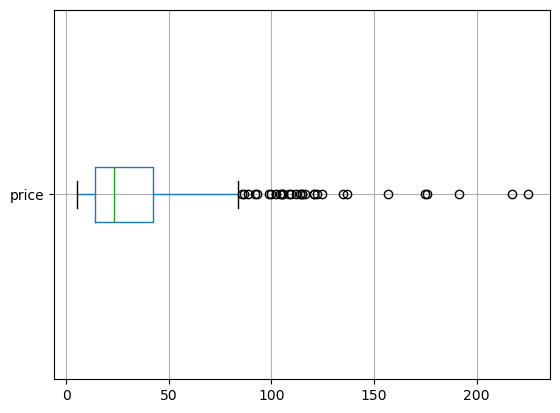

In [251]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge.boxplot(column='price', vert=False)
plt.show()

In [252]:
#Autre méthode avec plotly express
fig = px.box(df_merge, y="price", title="Distribution des prix des produits", width=600, height=400)
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [253]:
#Calculer la moyenne du prix
#Calculer l'écart-type du prix

moyenne = df_merge['price'].mean()
ecart_type = df_merge['price'].std()
z_score = (df_merge['price']- moyenne) / ecart_type
print(f"La moyenne du prix est : {moyenne:.2f}, l'écart-type : {ecart_type:.2f}.")

La moyenne du prix est : 32.33, l'écart-type : 27.60.


In [254]:
#Calculer le Z-score (distance en écart-type d'une valeur par rapport à la moyenne)
df_merge['z__score'] = (df_merge['price']- moyenne) / ecart_type

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_26196\286589839.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [255]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
# On peut regarder le premier produit à partir duquel la valeur de z-score dépasse 3
df_merge[['price', 'z__score']][df_merge['z__score'] > 3].sort_values(by='z__score', ascending=True)

,price,z__score
302,116.4,3.046286
406,121.0,3.212975
630,121.0,3.212975
419,122.0,3.249211
153,124.8,3.350674
392,135.0,3.720288
226,137.0,3.792762
212,157.0,4.517496
210,175.0,5.169756
448,176.0,5.205993


In [256]:
# Ou regarder la valeur de prix pour un z-score = 3
seuil = 3 * ecart_type + moyenne
print(f"le seuil pour un z-score à 3 est : {seuil:.2f}.")

le seuil pour un z-score à 3 est : 115.12.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [257]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge.describe()

,product_id,total_sales,stock_quantity,price,purchase_price,z__score
count,714.000000,714.000000,714.000000,714.000000,714.000000,7.140000e+02
mean,5032.557423,8.054622,23.445378,32.333683,16.904006,-4.727000e-17
std,790.510878,4.161344,22.219243,27.596332,14.827384,1.000000e+00
min,3847.000000,0.000000,0.000000,5.200000,2.740000,-9.832351e-01
25%,4280.250000,5.000000,9.000000,14.062500,7.240000,-6.620874e-01
50%,4796.000000,8.000000,20.000000,23.450000,12.305000,-3.219154e-01
75%,5710.500000,11.000000,30.000000,42.075000,22.030000,3.529932e-01
max,7338.000000,36.000000,145.000000,225.000000,137.810000,6.981591e+00


In [258]:
#Définir un seuil pour les articles "outliers" en prix
# On calcule Q1 (25%) et Q3 (75%)
q1 = df_merge['price'].quantile(0.25)
q3 = df_merge['price'].quantile(0.75)

# On calcule l'IQR (l'écart entre les deux)
iqr = q3 - q1

seuil_haut = q3 + 1.5 * iqr

print(f"Le seuil de prix pour les articles outliers est de {seuil_haut:.2f}€.")

Le seuil de prix pour les articles outliers est de 84.09€.


In [259]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

#Nombre d'outliers (ceux qui dépassent le seuil)
nb_outliers = len(df_merge[df_merge['price'] > seuil_haut])

#Calcul de la proportion (en pourcentage)
proportion_outliers = (nb_outliers / len(df_merge)) * 100

print(f"Nombre d'outliers détectés : {nb_outliers}")
print(f"Proportion des outliers : {proportion_outliers:.2f} %")

Nombre d'outliers détectés : 31
Proportion des outliers : 4.34 %


In [260]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
# Je soupconne que ce sont des spiritueux plus chers ou des vins de meilleurs qualité, pour cela il faut aller les regarder
outliers_ventes = df_merge[df_merge['price'] > seuil_haut].sort_values('price', ascending=False)
outliers_ventes

,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price,z__score
598,4352,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11.0,0,225.0,137.81,6.981591
689,5001,Vin,David Duband Charmes-Chambertin Grand Cru 2014,2.0,18,217.5,116.87,6.709816
319,5892,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,6.0,98,191.3,116.06,5.760415
448,4402,Cognac,Cognac Frapin VIP XO,3.0,11,176.0,78.25,5.205993
210,5767,Vin,Camille Giroud Clos de Vougeot 2016,4.0,12,175.0,90.42,5.169756
212,4406,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,4.0,12,157.0,69.08,4.517496
226,4904,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,3.0,9,137.0,67.95,3.792762
392,6126,Champagne,Champagne Gosset Célébris Vintage 2007,5.0,138,135.0,80.33,3.720288
153,5612,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,1.0,19,124.8,66.41,3.350674
419,5917,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,3.0,12,122.0,54.24,3.249211


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [261]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge['CA'] = df_merge['price'] * df_merge['total_sales']
#Calculer la somme de la colonne "ca_par_article"
somme_ca = df_merge['CA'].sum()
#Ce résultat correspond au chiffre d'affaire du site web
print(f"Le chiffre d'affaires total généré par le site web est de : {somme_ca:.2f} €")

Le chiffre d'affaires total généré par le site web est de : 143680.10 €


C:\Users\MonCompte\AppData\Local\Temp\ipykernel_26196\3411840286.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [262]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge = df_merge.sort_values(by='CA', ascending=False)

In [263]:
#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)

In [264]:
#Afficher les 20 premiers articles en CA
df_topCA = df_merge.head(20)
df_topCA

,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price,z__score,CA
0,4352,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11.0,0,225.0,137.81,6.981591,2475.0
1,5892,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,6.0,98,191.3,116.06,5.760415,1147.8
2,4353,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,14.0,127,79.5,45.91,1.709152,1113.0
3,5826,Vin,Agnès Levet Côte Rôtie Améthyste 2017,20.0,34,41.2,21.71,0.321286,824.0
4,6212,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,7.0,16,115.0,59.42,2.995554,805.0
5,5026,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,9.0,101,86.8,50.13,1.973680,781.2
6,5008,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,7.0,12,105.0,56.42,2.633187,735.0
7,5767,Vin,Camille Giroud Clos de Vougeot 2016,4.0,12,175.0,90.42,5.169756,700.0
8,6126,Champagne,Champagne Gosset Célébris Vintage 2007,5.0,138,135.0,80.33,3.720288,675.0
9,5025,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...,6.0,136,112.0,68.60,2.886844,672.0


In [265]:
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_topCA, 
             x='CA', 
             y='post_title', 
             color = 'product_type',
             width=1500,
             height=2000,
             title="Top 20 des articles par Chiffre d'Affaires",
             labels={'CA': 'Chiffre d\'Affaires (€)', 'post_title': 'Nom du produit'})

fig.update_layout(yaxis={'categoryorder':'total ascending'}, 
                  height=800)

fig.show()

In [266]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge['%CA'] = 100 * (df_merge['CA'] / df_merge['CA'].sum())
df_merge

,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price,z__score,CA,%CA
0,4352,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11.0,0,225.0,137.81,6.981591,2475.0,1.722577
1,5892,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,6.0,98,191.3,116.06,5.760415,1147.8,0.798858
2,4353,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,14.0,127,79.5,45.91,1.709152,1113.0,0.774638
3,5826,Vin,Agnès Levet Côte Rôtie Améthyste 2017,20.0,34,41.2,21.71,0.321286,824.0,0.573496
4,6212,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,7.0,16,115.0,59.42,2.995554,805.0,0.560272
...,...,...,...,...,...,...,...,...,...,...
709,4043,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,0.0,0,60.0,29.45,1.002536,0.0,0.000000
710,6038,Vin,I Fabbri Chianti Classico Gran Selezione 2015,0.0,0,48.5,25.31,0.585814,0.0,0.000000
711,4047,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,0.0,0,18.3,9.93,-0.508534,0.0,0.000000
712,4606,Vin,Catherine et Claude Maréchal Volnay 2017,0.0,0,50.1,24.59,0.643793,0.0,0.000000


In [267]:
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['%CA_cumule'] = df_merge['%CA'].cumsum()
df_merge

,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price,z__score,CA,%CA,%CA_cumule
0,4352,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11.0,0,225.0,137.81,6.981591,2475.0,1.722577,1.722577
1,5892,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,6.0,98,191.3,116.06,5.760415,1147.8,0.798858,2.521435
2,4353,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,14.0,127,79.5,45.91,1.709152,1113.0,0.774638,3.296072
3,5826,Vin,Agnès Levet Côte Rôtie Améthyste 2017,20.0,34,41.2,21.71,0.321286,824.0,0.573496,3.869569
4,6212,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,7.0,16,115.0,59.42,2.995554,805.0,0.560272,4.429841
...,...,...,...,...,...,...,...,...,...,...,...
709,4043,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,0.0,0,60.0,29.45,1.002536,0.0,0.000000,100.000000
710,6038,Vin,I Fabbri Chianti Classico Gran Selezione 2015,0.0,0,48.5,25.31,0.585814,0.0,0.000000,100.000000
711,4047,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,0.0,0,18.3,9.93,-0.508534,0.0,0.000000,100.000000
712,4606,Vin,Catherine et Claude Maréchal Volnay 2017,0.0,0,50.1,24.59,0.643793,0.0,0.000000,100.000000


In [268]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
len(df_merge[df_merge['%CA_cumule'] <= 80])

434

In [269]:
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print(f"La proportion d'articles représentant 80% du CA est de {100 * len(df_merge[df_merge['%CA_cumule'] <= 80]) / len(df_merge['%CA_cumule']):.2f} %.")

La proportion d'articles représentant 80% du CA est de 60.78 %.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [270]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge = df_merge.sort_values(by='total_sales', ascending=False)
df_merge['total_sales']

60     36.0
142    27.0
55     24.0
124    22.0
12     22.0
       ... 
709     0.0
710     0.0
711     0.0
712     0.0
713     0.0
Name: total_sales, Length: 714, dtype: float64

In [271]:
#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)

In [272]:
#Afficher les 20 premiers articles en quantité
df_top_qty = df_merge.head(20)

In [273]:
df_merge['total_sales'].sum()

np.float64(5751.0)

In [274]:
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(df_top_qty, 
             x='total_sales', 
             y='post_title', 
             color = 'product_type',
             hover_data="post_title",
             width=1500,
             height=2000,
             title="Top 20 des articles par quantités vendues",
             labels={'total_sales': 'Quantités', 'post_title': 'Nom du produit'})

fig.update_layout(yaxis={'categoryorder':'total ascending'}, 
                  height=800)

fig.show()

In [275]:
#############################
# Calculer le 20 / 80 en quantité #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge['%qty'] = 100 * (df_merge['total_sales'] / df_merge['total_sales'].sum())
df_merge


,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price,z__score,CA,%CA,%CA_cumule,%qty
0,4867,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0,121,9.9,4.86,-0.812923,356.4,0.248051,22.799330,0.625978
1,4203,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0,74,9.9,5.01,-0.812923,267.3,0.186038,40.239045,0.469484
2,4275,Vin,I Fabbri Chianti Classico Lamole 2017,24.0,62,14.9,7.78,-0.631739,357.6,0.248886,21.557543,0.417319
3,4726,Vin,François Baur Pinot Noir Schlittweg 2017,22.0,0,12.7,6.82,-0.711460,279.4,0.194460,36.807324,0.382542
4,4647,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0,45,28.5,14.14,-0.138920,627.0,0.436386,8.224243,0.382542
...,...,...,...,...,...,...,...,...,...,...,...,...
709,4043,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,0.0,0,60.0,29.45,1.002536,0.0,0.000000,100.000000,0.000000
710,6038,Vin,I Fabbri Chianti Classico Gran Selezione 2015,0.0,0,48.5,25.31,0.585814,0.0,0.000000,100.000000,0.000000
711,4047,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,0.0,0,18.3,9.93,-0.508534,0.0,0.000000,100.000000,0.000000
712,4606,Vin,Catherine et Claude Maréchal Volnay 2017,0.0,0,50.1,24.59,0.643793,0.0,0.000000,100.000000,0.000000


In [276]:
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['%qty_cumule'] = df_merge['%qty'].cumsum()
df_merge

,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price,z__score,CA,%CA,%CA_cumule,%qty,%qty_cumule
0,4867,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0,121,9.9,4.86,-0.812923,356.4,0.248051,22.799330,0.625978,0.625978
1,4203,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0,74,9.9,5.01,-0.812923,267.3,0.186038,40.239045,0.469484,1.095462
2,4275,Vin,I Fabbri Chianti Classico Lamole 2017,24.0,62,14.9,7.78,-0.631739,357.6,0.248886,21.557543,0.417319,1.512780
3,4726,Vin,François Baur Pinot Noir Schlittweg 2017,22.0,0,12.7,6.82,-0.711460,279.4,0.194460,36.807324,0.382542,1.895323
4,4647,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0,45,28.5,14.14,-0.138920,627.0,0.436386,8.224243,0.382542,2.277865
...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,4043,Vin,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,0.0,0,60.0,29.45,1.002536,0.0,0.000000,100.000000,0.000000,100.000000
710,6038,Vin,I Fabbri Chianti Classico Gran Selezione 2015,0.0,0,48.5,25.31,0.585814,0.0,0.000000,100.000000,0.000000,100.000000
711,4047,Vin,Pierre Gaillard Côtes-du-Rhône Blanc Les Gendr...,0.0,0,18.3,9.93,-0.508534,0.0,0.000000,100.000000,0.000000,100.000000
712,4606,Vin,Catherine et Claude Maréchal Volnay 2017,0.0,0,50.1,24.59,0.643793,0.0,0.000000,100.000000,0.000000,100.000000


In [277]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
len(df_merge[df_merge['%qty_cumule'] <= 80])

433

In [278]:
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print(f"La proportion d'articles représentant 80% du CA est de {100 * len(df_merge[df_merge['%qty_cumule'] <= 80]) / len(df_merge['%qty_cumule']):.2f} %.")

La proportion d'articles représentant 80% du CA est de 60.64 %.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [279]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np
#Création de la colonne Rotation de stock
df_merge['rotation_stock'] = df_merge['stock_quantity'] / df_merge['total_sales']
df_merge['rotation_stock'].describe()

count    692.000000
mean            inf
std             NaN
min        0.000000
25%        1.750000
50%        2.408333
75%        3.100000
max             inf
Name: rotation_stock, dtype: float64

In [280]:
#Remplacement des "inf" par 0
df_merge['rotation_stock'] = df_merge['rotation_stock'].replace(np.inf, 0)
df_merge['rotation_stock']= df_merge['rotation_stock'].fillna(0)

In [281]:
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge = df_merge.sort_values(by='rotation_stock', ascending=False).reset_index(drop=True)
df_merge['rotation_stock']

0      31.250000
1      27.600000
2      27.000000
3      25.000000
4      23.666667
         ...    
709     0.000000
710     0.000000
711     0.000000
712     0.000000
713     0.000000
Name: rotation_stock, Length: 714, dtype: float64

In [282]:
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop_20 = df_merge.head(20)

fig = px.bar(flop_20, 
             x='rotation_stock', 
             y='post_title', 
             color='product_type',
             hover_data="post_title",
             width=1500,
             height=2000,
             title="Flop 20 des produits qui ont le plus de mois de stocks",
             labels={'rotation_stock': 'Mois de stocks', 'post_title': 'Nom du produit'})

fig.update_layout(yaxis={'categoryorder':'total ascending'}, 
                  height=800)

fig.show()

In [283]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge['valorisation_euros'] = df_merge['stock_quantity'] * df_merge['price']

In [284]:
df_merge['valorisation_euros']

0       6625.0
1      18630.0
2       4179.6
3       7375.0
4       2662.5
        ...   
709        0.0
710        0.0
711        0.0
712        0.0
713        0.0
Name: valorisation_euros, Length: 714, dtype: float64

In [285]:
#Calculer la somme de la colonne "Valorisation_stock_euros"
print(f"La valeur totale du stock est de {df_merge['valorisation_euros'].sum():,.2f} €.")

La valeur totale du stock est de 494,637.90 €.


In [286]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print(f"La nombre de produits en stock est de {df_merge['stock_quantity'].sum()} bouteilles.")

La nombre de produits en stock est de 16740 bouteilles.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [287]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
tva = 0.20 
df_merge['prix_ht'] = df_merge['price'] / (1 + tva)

[Source](https://entreprendre.service-public.gouv.fr/vosdroits/F32101) TVA sur les boissons

In [288]:
#Création de la colonne Taux de marge
df_merge['marge'] = df_merge['prix_ht'] - df_merge['purchase_price']

In [289]:
df_merge['taux_marge'] = (df_merge['marge']/df_merge['prix_ht']) * 100

In [290]:
#Afficher le prix minimum de la colonne "taux_marge"
print(f"Le taux de marge minimum est de {df_merge['taux_marge'].min():.2f}%.")

Le taux de marge minimum est de -634.99%.


In [291]:
#Afficher le prix maximum de la colonne "taux_marge"
print(f"Le taux de marge maximum est de {df_merge['taux_marge'].max():.2f}%.")

Le taux de marge maximum est de 47.76%.


In [292]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_marge_neg = df_merge[df_merge['taux_marge'] < 0]
df_marge_neg

,product_id,product_type,post_title,total_sales,stock_quantity,price,purchase_price,z__score,CA,%CA,%CA_cumule,%qty,%qty_cumule,rotation_stock,valorisation_euros,prix_ht,marge,taux_marge
673,4355,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,0.0,97,12.65,77.48,-0.713272,0.0,0.0,100.0,0.0,100.0,0.0,1227.05,10.541667,-66.938333,-634.988142


In [293]:
#probablement une virgule mal placée, le vrai prix doit être 126.5€

In [294]:
#Création d'un dataframe avec les taux positifs
df_benef = df_merge[df_merge['taux_marge'] > 0]

In [295]:
#Afficher le prix minimum de la colonne "taux_marge".
print(f"Le taux de marge minimum est de {df_benef['taux_marge'].min():.2f}%.")

Le taux de marge minimum est de 22.78%.


In [296]:
#Afficher le prix maximum de la colonne "taux_marge"
print(f"Le taux de marge maximum est de {df_benef['taux_marge'].max():.2f}%.")

Le taux de marge maximum est de 47.76%.


In [297]:
df_benef['benef_net'] = (df_benef['taux_marge'] * df_benef['CA']) /100

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_26196\2587008206.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [298]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_par_type = df_benef.groupby('product_type')['taux_marge'].mean().reset_index()

In [299]:
df_marge_par_type.rename(columns={'taux_marge': 'taux_marge_moyenne'}, inplace=True)
df_marge_par_type= df_marge_par_type.sort_values(by='taux_marge_moyenne', ascending=False)
df_marge_par_type

,product_type,taux_marge_moyenne
1,Cognac,45.067614
5,Whisky,44.918865
2,Gin,42.800000
4,Vin,38.012262
0,Champagne,28.488539
3,Huile d'olive,24.998198


In [300]:
#Affichage dans un graphique du taux de marge par type de produit

fig = px.bar(df_marge_par_type, 
             x='product_type', 
             y='taux_marge_moyenne', 
             color='product_type',
             hover_data=["product_type"],
             width=1000,
             height=500,
             title="Taux de marge moyen par type de produit",
             labels={'marge_moyenne': 'Marge_moyenne', 'product_type': 'Type de produit'})

fig.update_layout(yaxis={'categoryorder':'total ascending'}, 
                 height=600)

fig.show()

In [301]:
#création d'un dataset avec la somme de bénéfices par type de produit
df_somme_benef_par_type = df_benef.groupby('product_type')['benef_net'].sum().reset_index()

In [302]:
# affichage en diagramme à barres 

fig = px.bar(df_somme_benef_par_type, 
             x='product_type', 
             y='benef_net', 
             color='product_type',
             hover_data=["product_type"],
             text='benef_net',
             width=1000,
             height=500,
             title="Somme des bénéfices par type de produit",
             labels={'benef_net': 'Bénéfices moyen', 'product_type': 'Type de produit'})

fig.update_traces(texttemplate='%{text:.2f} €', textposition='outside')

fig.update_layout(yaxis={'categoryorder':'total ascending'}, 
                 height=600)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

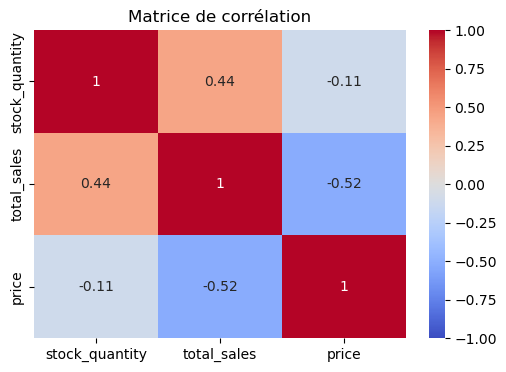

In [303]:
############################
# Analyse des corrélations #
############################

#Création d'une heatmap de corrélation avec les variables stock, sales et price

corr = df_merge[['stock_quantity', 'total_sales', 'price']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()


In [304]:
corr

,stock_quantity,total_sales,price
stock_quantity,1.000000,0.438930,-0.106654
total_sales,0.438930,1.000000,-0.516258
price,-0.106654,-0.516258,1.000000


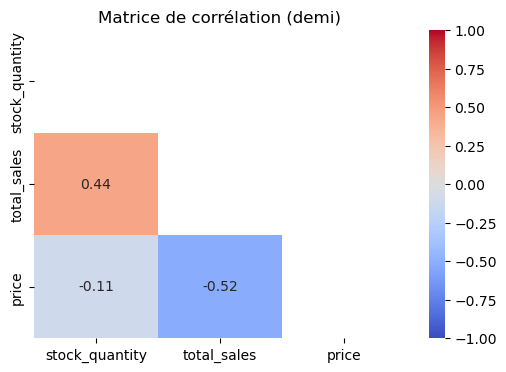

In [305]:
#On peut également créer un mask pour n'afficher qu'une demi heatmap

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, mask=mask, vmin=-1, vmax=1)
plt.title("Matrice de corrélation (demi)")
plt.show()

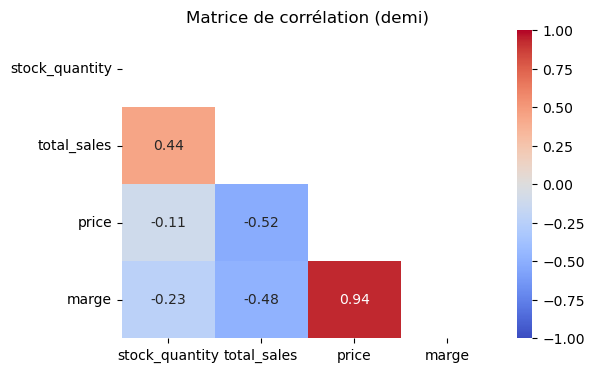

In [306]:
#On peut également créer un mask pour n'afficher qu'une demi heatmap

corr = df_merge[['stock_quantity', 'total_sales', 'price', 'marge']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, mask=mask, vmin=-1, vmax=1 )
plt.title("Matrice de corrélation (demi)")
plt.show()

In [307]:
#Que peut-on conclure des corrélations ?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [308]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_merge.to_excel("Analyse_Bottleneck_Finale.xlsx", index=False)

print("Le fichier a été exporté avec succès !")

Le fichier a été exporté avec succès !
